# Xây dựng CNN trên Fashion MNIST bằng TensorFlow/Keras
Notebook này sử dụng TensorFlow để xây dựng, huấn luyện và đánh giá mô hình CNN.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
import struct

print("TensorFlow version:", tf.__version__)

if not os.path.exists('../saved_models'):
    os.makedirs('../saved_models')

TensorFlow version: 2.21.0


## 1. Load Dữ liệu

In [2]:
def load_idx_images(filename):
    with open(filename, 'rb') as f:
        magic, size, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(size, rows, cols)
    return data

def load_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train = load_idx_images('../data/train-images-idx3-ubyte')
y_train = load_idx_labels('../data/train-labels-idx1-ubyte')
X_test = load_idx_images('../data/t10k-images-idx3-ubyte')
y_test = load_idx_labels('../data/t10k-labels-idx1-ubyte')

# Chuẩn hóa
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Reshape cho TensorFlow: (N, H, W, C)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (60000, 28, 28, 1), Test shape: (10000, 28, 28, 1)


## 2. Trực quan hóa dữ liệu

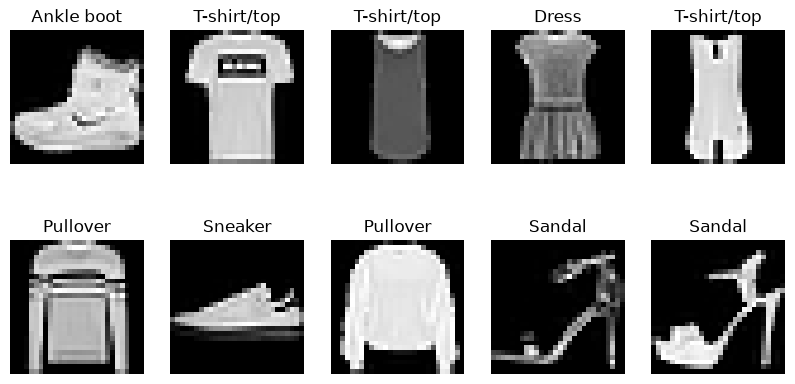

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

## 3. Định nghĩa Mô hình CNN (TensorFlow)

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

D:\Anaconda\envs\pytorch\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

## 4. Huấn luyện

In [5]:
# Callback để lưu model tốt nhất
checkpoint_path = '../saved_models/fashion_mnist_tf_best.keras'
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path, 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_data=(X_test, y_test),
    callbacks=[model_checkpoint]
)

Epoch 1/10
937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8197 - loss: 0.5115
Epoch 1: val_accuracy improved from None to 0.88130, saving model to ../saved_models/fashion_mnist_tf_best.keras

Epoch 1: finished saving model to ../saved_models/fashion_mnist_tf_best.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.8197 - loss: 0.5113 - val_accuracy: 0.8813 - val_loss: 0.3326
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8719 - loss: 0.3553
Epoch 2: val_accuracy improved from 0.88130 to 0.88850, saving model to ../saved_models/fashion_mnist_tf_best.keras

Epoch 2: finished saving model to ../saved_models/fashion_mnist_tf_best.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.8719 - loss: 0.3553 - val_accuracy: 0.8885 - val_loss: 0.3070
Epoch 3/10
936/938 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8874 - loss: 0.3111
Epoch 3: val_accuracy improved from 0.88850 to 0.89670, saving model to ../saved_models/fashion_mnist_tf_best.kera

## 5. Đánh giá và Trực quan hóa

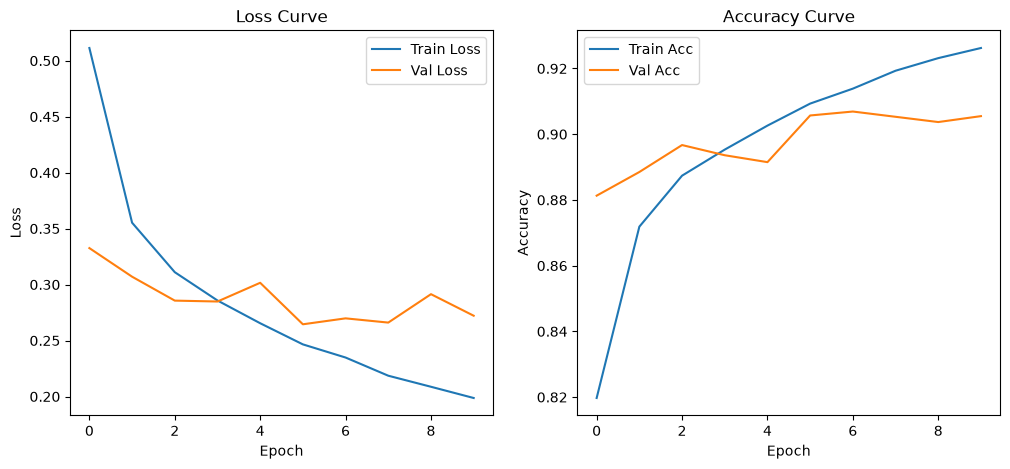

In [6]:
# Learning Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


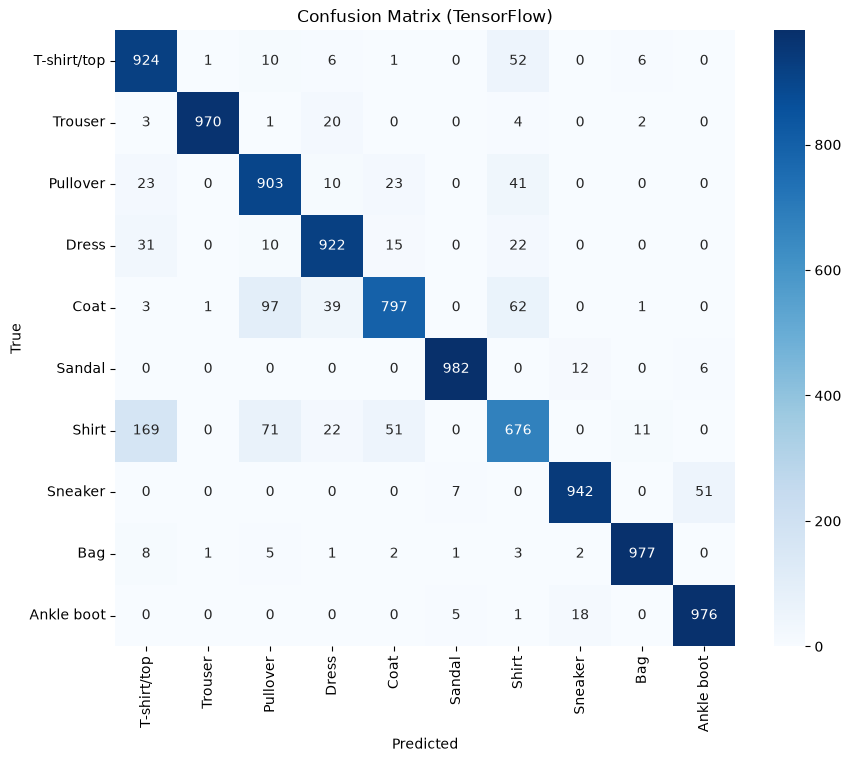

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.92      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.82      0.90      0.86      1000
       Dress       0.90      0.92      0.91      1000
        Coat       0.90      0.80      0.84      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.79      0.68      0.73      1000
     Sneaker       0.97      0.94      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.94      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [7]:
# Load best model
best_model = tf.keras.models.load_model('../saved_models/fashion_mnist_tf_best.keras')

# Dự đoán
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (TensorFlow)')
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

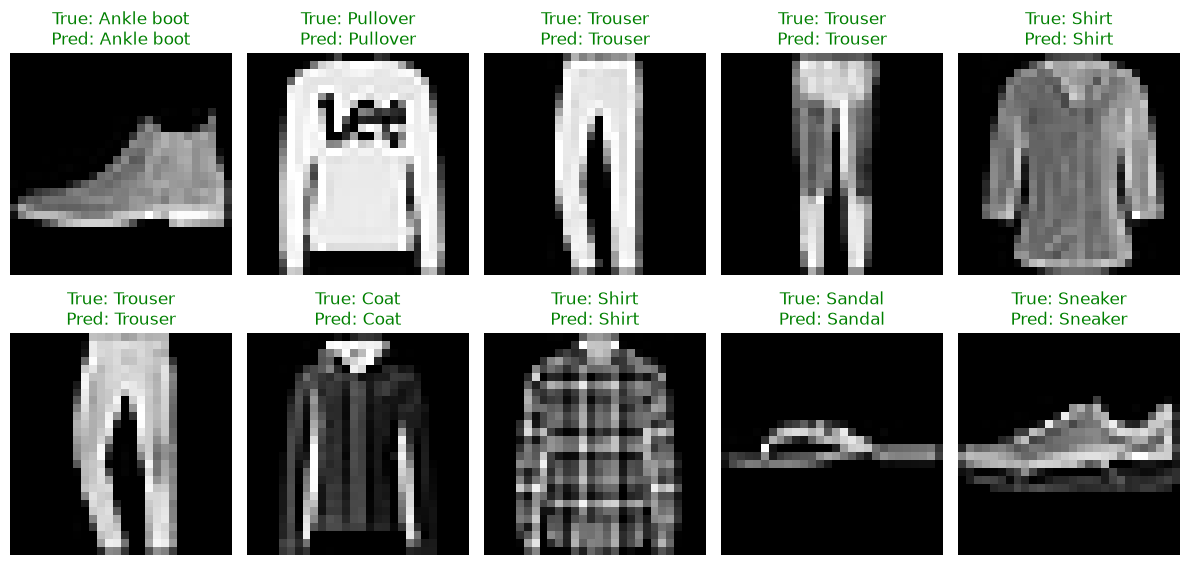

In [8]:
# Hiển thị một số dự đoán
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"True: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()